# DNA Sequence Analysis Project
**Author:** Abubaker Izzeldeen  
**Course:** BIO-613 Programming for Bioinformatics  
**Date:** 2026-09-10  

## Objective
This notebook demonstrates a reproducible analysis of DNA sequences by calculating the GC Content using BioPython.

In [2]:
from Bio.Seq import Seq

# Define DNA sequence
dna = Seq("ATGGCGCGCTTA")

# Calculate GC Content percentage
gc_content = (dna.count("G") + dna.count("C")) / len(dna) * 100

# Display Results
print("DNA Sequence:", dna)
print(f"GC Content: {round(gc_content, 2)}%")

DNA Sequence: ATGGCGCGCTTA
GC Content: 58.33%


Generating Nucleotide Distribution Chart...


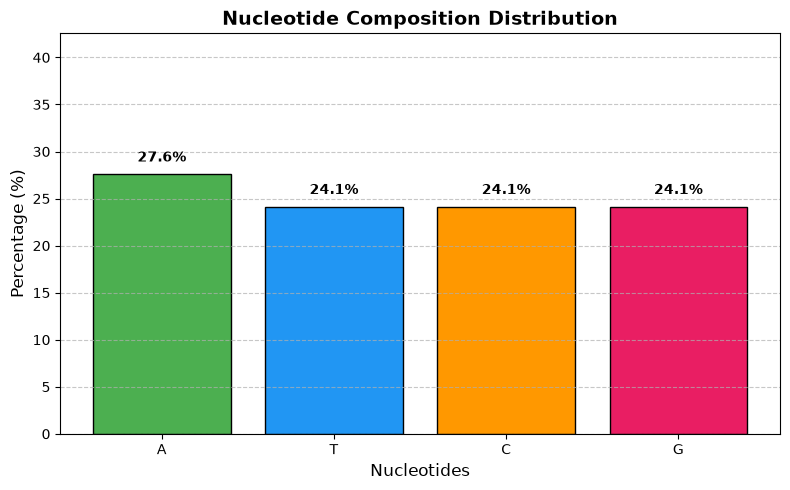

Generating GC Content Sliding Window Chart...


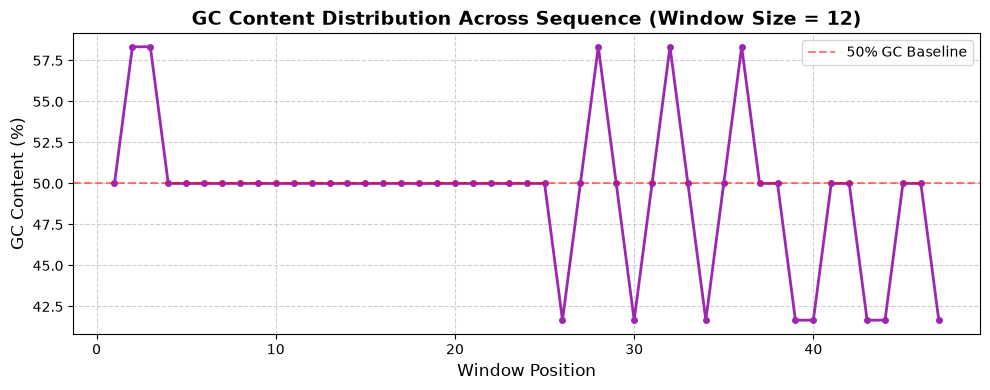

In [1]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_nucleotide_distribution(sequence):
    """
    Plots a bar chart showing the frequency and percentage of each nucleotide (A, T, C, G).
    """
    sequence = sequence.upper()
    total_length = len(sequence)
    counts = Counter(sequence)
    
    nucleotides = ['A', 'T', 'C', 'G']
    frequencies = [counts.get(n, 0) for n in nucleotides]
    percentages = [(count / total_length) * 100 for count in frequencies]

    # Create Bar Chart
    plt.figure(figsize=(8, 5))
    bars = plt.bar(nucleotides, percentages, color=['#4CAF50', '#2196F3', '#FF9800', '#E91E63'], edgecolor='black')
    
    # Add values on top of each bar
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title('Nucleotide Composition Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Nucleotides', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.ylim(0, max(percentages) + 15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_gc_sliding_window(sequence, window_size=10):
    """
    Plots the GC content variation along the DNA sequence using a sliding window.
    """
    sequence = sequence.upper()
    gc_values = []
    
    # Calculate GC content for each window
    for i in range(len(sequence) - window_size + 1):
        sub_seq = sequence[i:i + window_size]
        gc_count = sub_seq.count('G') + sub_seq.count('C')
        gc_pct = (gc_count / window_size) * 100
        gc_values.append(gc_pct)

    # Create Line Plot
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(gc_values) + 1), gc_values, color='#9C27B0', linewidth=2, marker='o', markersize=4)
    
    plt.title(f'GC Content Distribution Across Sequence (Window Size = {window_size})', fontsize=14, fontweight='bold')
    plt.xlabel('Window Position', fontsize=12)
    plt.ylabel('GC Content (%)', fontsize=12)
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% GC Baseline')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# =========================================================
# Example Execution
# =========================================================
if __name__ == "__main__":
    # Sample DNA sequence for visualization
    sample_dna = "ATGCGATCGATCGATCGATCGATCGATCGATCGATCAGCTAGCTAGCTAAGCTAGCTA"
    
    print("Generating Nucleotide Distribution Chart...")
    plot_nucleotide_distribution(sample_dna)
    
    print("Generating GC Content Sliding Window Chart...")
    plot_gc_sliding_window(sample_dna, window_size=12)